<a href="https://colab.research.google.com/github/a4kashhh/MaxBetweennessGNN/blob/main/HopesNeverDie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import networkx as nx
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
#creating BA network + their properities
G = nx.barabasi_albert_graph(n=30,m=4,seed=42)
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 30
Edges: 104


In [4]:
#phir se we are doing some properties stuffu + slicing
degree = dict(G.degree())
clustering = nx.clustering(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)
features = []
for node in G.nodes():
    features.append([degree[node],clustering[node],betweenness[node],closeness[node],pagerank[node]])
x = torch.tensor(features,dtype=torch.float)
print(x.shape)
print(x[:10])

torch.Size([30, 5])
tensor([[1.7000e+01, 2.5000e-01, 1.7098e-01, 7.0732e-01, 7.5841e-02],
        [4.0000e+00, 5.0000e-01, 4.0364e-03, 5.2727e-01, 2.0600e-02],
        [4.0000e+00, 6.6667e-01, 2.3868e-03, 5.0877e-01, 2.0759e-02],
        [1.0000e+01, 4.0000e-01, 3.7203e-02, 6.0417e-01, 4.5009e-02],
        [3.0000e+00, 6.6667e-01, 4.9261e-04, 5.0000e-01, 1.6639e-02],
        [1.4000e+01, 2.5275e-01, 1.0034e-01, 6.5909e-01, 6.3214e-02],
        [1.4000e+01, 2.7473e-01, 1.0099e-01, 6.5909e-01, 6.2200e-02],
        [1.5000e+01, 2.4762e-01, 1.2085e-01, 6.5909e-01, 6.7380e-02],
        [1.2000e+01, 3.1818e-01, 6.2984e-02, 6.1702e-01, 5.4612e-02],
        [1.1000e+01, 2.3636e-01, 7.2947e-02, 6.0417e-01, 5.1877e-02]])


In [5]:
degree, clustering, betweenness, pagerank

({0: 17,
  1: 4,
  2: 4,
  3: 10,
  4: 3,
  5: 14,
  6: 14,
  7: 15,
  8: 12,
  9: 11,
  10: 6,
  11: 5,
  12: 6,
  13: 5,
  14: 7,
  15: 6,
  16: 7,
  17: 6,
  18: 6,
  19: 6,
  20: 4,
  21: 5,
  22: 6,
  23: 4,
  24: 4,
  25: 5,
  26: 4,
  27: 4,
  28: 4,
  29: 4},
 {0: 0.25,
  1: 0.5,
  2: 0.6666666666666666,
  3: 0.4,
  4: 0.6666666666666666,
  5: 0.25274725274725274,
  6: 0.27472527472527475,
  7: 0.24761904761904763,
  8: 0.3181818181818182,
  9: 0.23636363636363636,
  10: 0.4666666666666667,
  11: 0.4,
  12: 0.3333333333333333,
  13: 0.7,
  14: 0.2857142857142857,
  15: 0.3333333333333333,
  16: 0.14285714285714285,
  17: 0.2,
  18: 0.3333333333333333,
  19: 0.3333333333333333,
  20: 0.8333333333333334,
  21: 0.3,
  22: 0.2,
  23: 0.5,
  24: 0.3333333333333333,
  25: 0.2,
  26: 0.5,
  27: 0.6666666666666666,
  28: 0.3333333333333333,
  29: 0.5},
 {0: 0.17098214114839733,
  1: 0.0040363987408322385,
  2: 0.002386816795683791,
  3: 0.037203467714551464,
  4: 0.0004926108374384237,

In [6]:
#misssiing edges findinggggggss
def generate_missing_edges(G):
    nodes = list(G.nodes())
    missing = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if not G.has_edge(i, j):
                missing.append((i, j))
    return missing
missing_edges = generate_missing_edges(G)
print("Total Missing Links:",len(missing_edges))

Total Missing Links: 331


In [7]:
#how much bwtnes centrality is affected by new edge
#**GROUND TRUTHHH**
def edge_impact(G,edge):
    bc_original = nx.betweenness_centrality(G)
    max_original = max(bc_original.values())
    G_new = G.copy()
    G_new.add_edge(edge[0],edge[1])
    bc_new = nx.betweenness_centrality(G_new)
    max_new = max(bc_new.values())
    return (max_original -max_new)

In [8]:
# randomly select at most 500 missing edges (reduces computation because BC calculation is expensive)
missing_edges = random.sample(missing_edges,min(500,len(missing_edges)))
scores = []
# check every sampled missing edge
for edge in missing_edges:
    # calculate how much maximum betweenness decreases
    # after adding this edge
    reduction = edge_impact(G,edge)
    scores.append(reduction)
    #transforming it into tensor cause we are dealing with pytorchh :)
scores = torch.tensor(scores,dtype=torch.float)
# display first 10 scores
# each score = BC reduction produced by that edge
print(scores[:10])

tensor([4.0494e-03, 3.0554e-03, 1.1300e-04, 3.9292e-04, 6.7618e-04, 3.2502e-03,
        2.0525e-04, 6.2498e-03, 8.7966e-05, 1.3459e-03])


In [9]:
#normalisation :) z score (x - xbar /  sd)
scores = (scores-scores.mean())/(scores.std())
print(scores.min())
print(scores.max())

tensor(-6.5479)
tensor(3.1166)


In [10]:
#cutoff //
# Create class labels
# 1 = important edge (top 10%)
# 0 = normal edge (remaining 90%)
threshold = np.percentile(scores.numpy(),90)
labels = torch.tensor([1 if s >= threshold else 0 for s in scores],dtype=torch.long)
# Count how many 0s and 1s were created
print(labels.unique(return_counts=True))

(tensor([0, 1]), tensor([297,  34]))


In [11]:
#converting missing_edges from a Python list into a PyTorch tensor.
candidate_edges = torch.tensor(missing_edges,dtype=torch.long).t()
print(candidate_edges.shape)

torch.Size([2, 331])


In [12]:
#generates triplets the
def generate_triplets(scores):
    idx = torch.argsort(scores,descending=True) #Sorting edges score ke basis pe
    n = len(idx)#Number of edges.
    top = idx[:n//3] #take third best
    middle = idx[n//3:2*n//3] #middle third
    bottom = idx[2*n//3:] #bottom third
    triplets = []
    for i in range( #Find the smallest list length and loop that many times.
        min(len(top),len(middle),len(bottom))):
        triplets.append( #Add a new element to the triplets list.
            (top[i],middle[i],bottom[i]))
    return triplets #wapas se us function pe
triplets = generate_triplets(scores)
print(len(triplets))

110


In [13]:
!pip install torch_geometric
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import from_networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.5 MB/s eta 0:00:00


In [14]:
data = from_networkx(G) #conbert NetworkX graph into a PyTorch Geometric graph object
edge_index = data.edge_index #Extract graph connections.
print(edge_index.shape) #Print size of edge index

torch.Size([2, 208])


In [15]:
class GraphSAGEEncoder(nn.Module):
    def __init__( self, input_dim, hidden_dim=32):  #Constructor // input_dim - Number of input features per node.
        super().__init__()
        self.conv1 = SAGEConv(input_dim,hidden_dim)
        self.conv2 = SAGEConv(hidden_dim,hidden_dim)
    def forward(self,x,edge_index):
        x = self.conv1(x,edge_index) #Aggreg neighbor information.
        x = F.relu(x)
        x = self.conv2(x,edge_index) #Perform another round  message passing.
        return x

In [16]:
class MLPClassifier(nn.Module):
    def __init__(self): #Constructor
        super().__init__()
        self.fc1 = nn.Linear(64,32)
        self.fc2 = nn.Linear(32,2) #Binary classification: // Class 0 = Not Important Edge // Class 1 = Important Edge
    def forward(self,edge_emb):
        x = F.relu(self.fc1(edge_emb))
        return self.fc2(x)

$$
\text{BINARY CLASSFICATION}_{(N=1)}
=
y\log(p)
+
(1-y)\log(1-p)
$$

In [17]:
class MLPRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64,32)
        self.fc2 = nn.Linear(32,1) #one importance score per edge groupp
    def forward(self,edge_emb):
        x = F.relu(self.fc1(edge_emb))
        return self.fc2(x) #ranking score.

In [18]:
class BetweennessLinkPredictor(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.encoder = (GraphSAGEEncoder(input_dim))#Create GraphSAGE network.
        self.classifier = (MLPClassifier())#Create MPL 1 for CLASSIFICATION
        self.ranker = (MLPRanker()) #creates MLP 2 i.e for ranking
    def forward(self,x,edge_index,candidate_edges): #x - node features // edge_index - graph connection // candidate_edges - Missing edges to evaluate
        node_emb = self.encoder(x,edge_index) # calls  GraphSAGE.
        src = candidate_edges[0] #take source nodes
        dst = candidate_edges[1] #take destination nodes
        edge_emb = torch.cat([node_emb[src],node_emb[dst]],dim=1) #Create an edge embedding from two node embeddings.
        class_logits = (self.classifier(edge_emb)) #Send edge embedding MLP1 Classifier
        rank_scores = (self.ranker(edge_emb)) #Send edge embedding MLP2 RANKER
        return (class_logits,rank_scores)

In [19]:
def triplet_loss(rank_scores,triplets,margin=1.0): #Inputs // rank_scores - Scores predicted by MLP Ranker //. triplets // margin - Minimum separation required.
    loss = 0 # total loss
    for a,b,c in triplets: #loop
        loss += F.relu(rank_scores[b]-rank_scores[a]+margin) #loss calcualtion (Is Good Edge ranked higher than Medium Edge? )
        loss += F.relu(rank_scores[c]-rank_scores[b]+margin)  #loss calcualtion(Is Medium Edge ranked higher than Bad Edge?)
    return (loss /len(triplets)) #averageloss


In [20]:
def total_loss(class_logits,labels,rank_scores,triplets):  #total_loss
  classification_loss = (F.cross_entropy(class_logits,labels)) #Calculate classifier erro
  ranking_loss = (triplet_loss(rank_scores,triplets)) #Calculate ranking error.
  return (classification_loss+ranking_loss) #Add both losi

In [21]:
model = (BetweennessLinkPredictor(input_dim=x.shape[1])) # Create model
optimizer = torch.optim.Adam(model.parameters(),lr=0.001) # Create model
for epoch in range(100): # Training loop
    class_logits, rank_scores = model(x,edge_index,candidate_edges)     #Forward pass
    loss = total_loss(class_logits,labels,rank_scores,triplets) #Compute loss
    optimizer.zero_grad()
    loss.backward() #backwarrdd propagration
    optimizer.step() #Compute loss
    if epoch % 10 == 0:
        print(epoch,loss.item())

0 2.347350835800171
10 2.2197818756103516
20 2.139796733856201
30 2.1015753746032715
40 2.058183431625366
50 2.006481409072876
60 1.9443531036376953
70 1.867899775505066
80 1.7826271057128906
90 1.6935245990753174


In [22]:
from scipy.stats import pearsonr,spearmanr,kendalltau
with torch.no_grad(): #no gradient
    class_logits,rank_scores = model(x,edge_index,candidate_edges) #GraphSAGE
pred = rank_scores.squeeze().cpu().numpy()
true = scores.cpu().numpy() #Ground truth scoes


pearson_corr= pearsonr(true,pred) #LOOKS FOR SOMERELATIONSHIP BTW TRUE AND PREDS
print("Pearson Correlation :", pearson_corr)


spearman_corr= spearmanr(true,pred) #LOOOKS FOR CORRECT ORDER
print(f"Spearman Correlation:", spearman_corr)


kendall_corr = kendalltau(true,pred) #LOOK HOW PAIRS ARE CORRECTLY RANKED
print(f"Kendall Tau :", kendall_corr)



Pearson Correlation : PearsonRResult(statistic=np.float32(0.49247882), pvalue=np.float64(1.2639277906407121e-21))
Spearman Correlation: SignificanceResult(statistic=np.float64(0.5747329257761298), pvalue=np.float64(1.7231418700124792e-30))
Kendall Tau : SignificanceResult(statistic=np.float64(0.40190791824368755), pvalue=np.float64(1.0290891724529939e-27))


**I STUDIED CORRELATION COEEFFIICIENT - WHHICH IS SOMETHING COV(X,Y)/SIGMAX*SIGMA Y**

### Pearson Correlation

$$
r=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

### Spearman Correlation

$$
\rho = 1-\frac{6\sum d_i^2}
{n(n^2-1)}
$$

### Kendall Tau

$$
\tau=\frac{C-D}
{\frac{n(n-1)}{2}}
$$

### mAP@k

$$
AP@k=\frac{1}{k}
\sum_{j=1}^{k} P@j \times Rel(j)
$$

$$
mAP@k=\frac{1}{N_{graphs}}
\sum_{i=1}^{N_{graphs}} AP_i@k
$$

In [23]:
#How many best edges did my model find in its TOP 100 predictions
def map_at_k(true_scores,pred_scores,k=100):
    true_top=set(np.argsort(true_scores)[-k:])
    pred_top=np.argsort(pred_scores)[::-1][:k]
    precision_sum=0 #running score
    hits=0 #correct predictions found
    for j,idx in enumerate(pred_top,start=1): #loop through predicted score
        if idx in true_top: #whether predicted edge is actually in true top-k.
            hits+=1
            precision_sum+=hits/j
    return precision_sum/k

mapk=map_at_k(true,pred)
print("mAP@10:",mapk)

mAP@10: 0.3838323716420406


In [24]:
true_top=np.argsort(true)[::-1][:10]
true_top


array([284, 198,  50, 203, 209, 129, 105, 223, 134,  71])

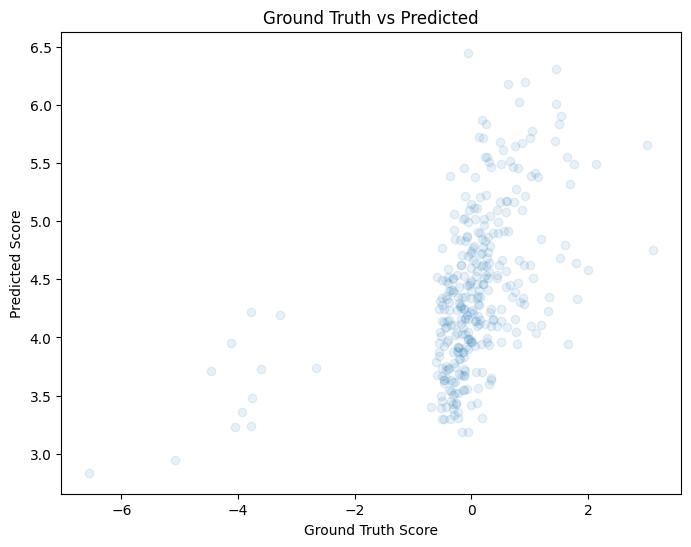

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(true,pred,alpha=0.1)
plt.xlabel("Ground Truth Score")
plt.ylabel("Predicted Score")
plt.title("Ground Truth vs Predicted")
plt.show()

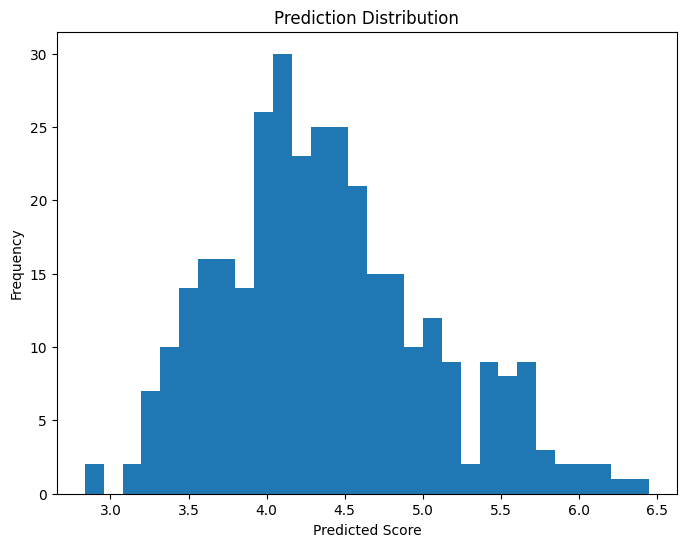

In [26]:
plt.figure(figsize=(8,6))
plt.hist(pred,bins=30)
plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Prediction Distribution")
plt.show()

In [27]:
#MINMAX
scores = (scores-scores.min())/(scores.max()-scores.min())
print(scores.min())
print(scores.max())

tensor(0.)
tensor(1.)


In [28]:
#DECIMAL UPSCALLING ( FROM GEMINI)
max_val = torch.max(torch.abs(scores))
# Calculate j
j = len(str(int(max_val.item())))
# Apply decimal scaling
scores = scores / (10 ** j)
print(scores.min())
print(scores.max())

tensor(0.)
tensor(0.1000)
